In [ ]:
import pandas as pd # Importar la librería pandas para manipulación de datos
import numpy as np # Importar la librería numpy para operaciones numéricas
import matplotlib.pyplot as plt # Importar matplotlib para visualización de datos
import seaborn as sns # Importar seaborn para visualización estadística de datos

from sklearn.preprocessing import StandardScaler # Importar StandardScaler para escalar los datos
from sklearn.cluster import KMeans # Importar KMeans para realizar el algoritmo de clustering
from sklearn.decomposition import PCA # Importar PCA para reducción de dimensionalidad
from sklearn.metrics import silhouette_score # Importar silhouette_score para evaluar la calidad del clustering

In [ ]:
# Cargar dataset

df = pd.read_csv("/content/telecom_customer_churn.csv") # Cargar el archivo CSV en un DataFrame de pandas

# Visualizar primeras filas

df.head() # Mostrar las primeras 5 filas del DataFrame para una vista previa

,Customer ID,Gender,Age,Married,Number of Dependents,City,Zip Code,Latitude,Longitude,Number of Referrals,...,Payment Method,Monthly Charge,Total Charges,Total Refunds,Total Extra Data Charges,Total Long Distance Charges,Total Revenue,Customer Status,Churn Category,Churn Reason
0,0002-ORFBO,Female,37,Yes,0,Frazier Park,93225,34.827662,-118.999073,2,...,Credit Card,65.6,593.30,0.00,0,381.51,974.81,Stayed,NaN,NaN
1,0003-MKNFE,Male,46,No,0,Glendale,91206,34.162515,-118.203869,0,...,Credit Card,-4.0,542.40,38.33,10,96.21,610.28,Stayed,NaN,NaN
2,0004-TLHLJ,Male,50,No,0,Costa Mesa,92627,33.645672,-117.922613,0,...,Bank Withdrawal,73.9,280.85,0.00,0,134.60,415.45,Churned,Competitor,Competitor had better devices
3,0011-IGKFF,Male,78,Yes,0,Martinez,94553,38.014457,-122.115432,1,...,Bank Withdrawal,98.0,1237.85,0.00,0,361.66,1599.51,Churned,Dissatisfaction,Product dissatisfaction
4,0013-EXCHZ,Female,75,Yes,0,Camarillo,93010,34.227846,-119.079903,3,...,Credit Card,83.9,267.40,0.00,0,22.14,289.54,Churned,Dissatisfaction,Network reliability


In [ ]:
variables_cluster = [ # Definir una lista de nombres de columnas a utilizar para el clustering
    'Tenure in Months',
    'Monthly Charge',
    'Total Charges',
    'Total Revenue',
    'Avg Monthly Long Distance Charges',
    'Avg Monthly GB Download',
    'Number of Referrals'
]

cluster_df = df[variables_cluster].copy() # Crear un nuevo DataFrame con solo las columnas seleccionadas para el clustering, haciendo una copia explícita para evitar warnings.

cluster_df.head() # Mostrar las primeras filas del DataFrame de clustering

,Tenure in Months,Monthly Charge,Total Charges,Total Revenue,Avg Monthly Long Distance Charges,Avg Monthly GB Download,Number of Referrals
0,9,65.6,593.30,974.81,42.39,16.0,2
1,9,-4.0,542.40,610.28,10.69,10.0,0
2,4,73.9,280.85,415.45,33.65,30.0,0
3,13,98.0,1237.85,1599.51,27.82,4.0,1
4,3,83.9,267.40,289.54,7.38,11.0,3


In [ ]:
cluster_df.isnull().sum() # Verificar la cantidad de valores nulos por columna en el DataFrame de clustering

,0
Tenure in Months,0
Monthly Charge,0
Total Charges,0
Total Revenue,0
Avg Monthly Long Distance Charges,682
Avg Monthly GB Download,1526
Number of Referrals,0


In [ ]:
for col in ['Avg Monthly Long Distance Charges', 'Avg Monthly GB Download']:
    if cluster_df[col].isnull().any():
        cluster_df[col] = cluster_df[col].fillna(cluster_df[col].mean()) # Imputar los valores nulos con la media de la columna

cluster_df.isnull().sum() # Verificar nuevamente los valores nulos después de la imputación

/tmp/ipykernel_4765/314139241.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cluster_df[col] = cluster_df[col].fillna(cluster_df[col].mean()) # Imputar los valores nulos con la media de la columna


,0
Tenure in Months,0
Monthly Charge,0
Total Charges,0
Total Revenue,0
Avg Monthly Long Distance Charges,0
Avg Monthly GB Download,0
Number of Referrals,0


In [ ]:
scaler = StandardScaler() # Inicializar el escalador de datos (StandardScaler)

cluster_scaled = scaler.fit_transform(cluster_df) # Escalar los datos del DataFrame de clustering *después* de la imputación para asegurar que no haya valores nulos.

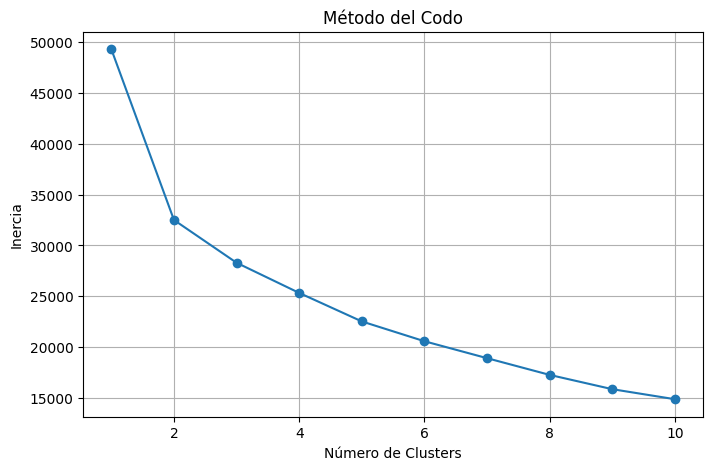

In [ ]:
inertia = [] # Lista para almacenar los valores de inercia

K = range(1, 11) # Rango de número de clusters a probar (de 1 a 10)

for k in K: # Iterar a través de cada número de cluster en el rango K
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10) # Inicializar KMeans con 'k' clusters y una semilla aleatoria
    kmeans.fit(cluster_scaled) # Entrenar el modelo KMeans con los datos escalados
    inertia.append(kmeans.inertia_) # Guardar el valor de inercia (suma de cuadrados de distancias a los centroides) para el 'k' actual

plt.figure(figsize=(8,5)) # Crear una figura para el gráfico con un tamaño específico
plt.plot(K, inertia, marker='o') # Graficar los valores de inercia contra el número de clusters
plt.title('Método del Codo') # Establecer el título del gráfico
plt.xlabel('Número de Clusters') # Establecer la etiqueta del eje X
plt.ylabel('Inercia') # Establecer la etiqueta del eje Y
plt.grid(True) # Habilitar la cuadrícula en el gráfico
plt.show() # Mostrar el gráfico

In [ ]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10) # Inicializar el modelo KMeans con 3 clusters (elegido por el método del codo)

clusters = kmeans.fit_predict(cluster_scaled) # Predecir el cluster al que pertenece cada punto de datos escalado

# Agregar clusters al dataframe

df['Cluster'] = clusters # Asignar las etiquetas de cluster a una nueva columna en el DataFrame original

In [ ]:
silhouette = silhouette_score(cluster_scaled, clusters) # Calcular el Silhouette Score para evaluar la calidad del clustering

print('Silhouette Score:', round(silhouette, 4)) # Imprimir el Silhouette Score redondeado a 4 decimales

Silhouette Score: 0.2556


In [ ]:
cluster_counts = df['Cluster'].value_counts() # Contar el número de ocurrencias de cada cluster

print(cluster_counts) # Imprimir el recuento de cada cluster

Cluster
0    3571
1    1999
2    1473
Name: count, dtype: int64


In [ ]:
cluster_profile = df.groupby('Cluster')[variables_cluster].mean() # Calcular la media de las variables de clustering para cada cluster

cluster_profile # Mostrar el perfil de los clusters

,Tenure in Months,Monthly Charge,Total Charges,Total Revenue,Avg Monthly Long Distance Charges,Avg Monthly GB Download,Number of Referrals
Cluster,,,,,,,
0,13.241949,57.335074,775.292635,1054.009490,24.709469,24.296751,0.343041
1,58.525763,92.070135,5415.158829,6929.182521,26.676464,26.485243,2.626313
2,43.326544,40.132926,1674.984888,2549.781358,25.263687,32.411765,4.936864


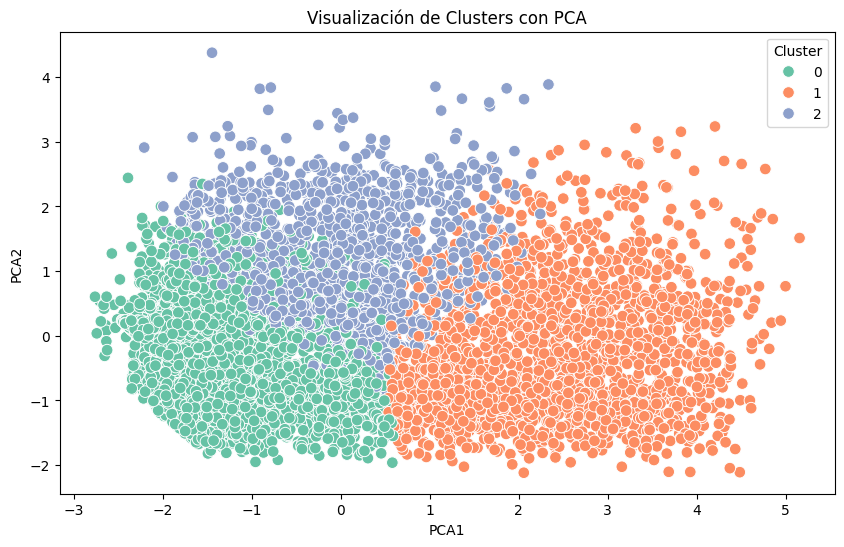

In [ ]:
pca = PCA(n_components=2) # Inicializar PCA para reducir la dimensionalidad a 2 componentes principales

pca_components = pca.fit_transform(cluster_scaled) # Aplicar PCA a los datos escalados

pca_df = pd.DataFrame(data=pca_components, columns=['PCA1', 'PCA2']) # Crear un DataFrame con los componentes principales
pca_df['Cluster'] = clusters # Añadir la columna de clusters al DataFrame de PCA

plt.figure(figsize=(10,6)) # Crear una figura para el gráfico con un tamaño específico

sns.scatterplot( # Crear un gráfico de dispersión
    x='PCA1', # Eje X: primer componente principal
    y='PCA2', # Eje Y: segundo componente principal
    hue='Cluster', # Colorear los puntos según el cluster al que pertenecen
    palette='Set2', # Usar la paleta de colores 'Set2'
    data=pca_df, # Usar el DataFrame con los componentes PCA y clusters
    s=70 # Tamaño de los puntos
)

plt.title('Visualización de Clusters con PCA') # Establecer el título del gráfico
plt.show() # Mostrar el gráfico

In [ ]:
cluster_churn = pd.crosstab(df['Cluster'], df['Customer Status']) # Crear una tabla de contingencia entre 'Cluster' y 'Customer Status'

cluster_churn # Mostrar la tabla de contingencia

Customer Status,Churned,Joined,Stayed
Cluster,,,
0,1476,418,1677
1,335,0,1664
2,58,36,1379


In [ ]:
cluster_churn_pct = pd.crosstab( # Crear una tabla de contingencia
    df['Cluster'], # Filas: Clusters
    df['Customer Status'], # Columnas: Customer Status (corregido de Churn)
    normalize='index' # Normalizar por fila para obtener porcentajes
) * 100 # Multiplicar por 100 para expresar como porcentaje

cluster_churn_pct # Mostrar la tabla de contingencia con porcentajes

Customer Status,Churned,Joined,Stayed
Cluster,,,
0,41.332960,11.705405,46.961635
1,16.758379,0.000000,83.241621
2,3.937542,2.443992,93.618466


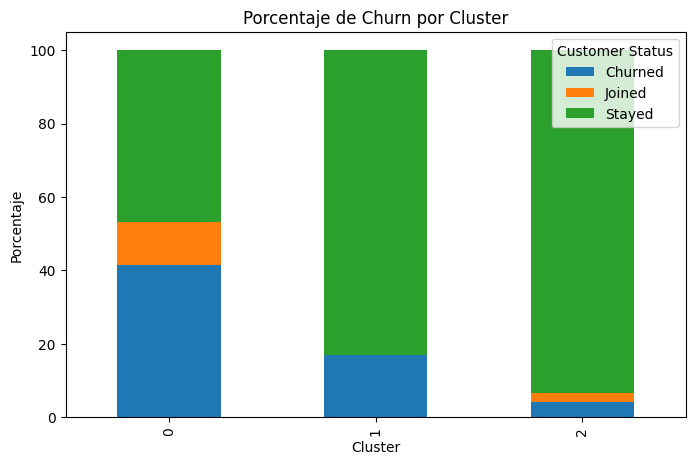

In [ ]:
cluster_churn_pct.plot(kind='bar', stacked=True, figsize=(8,5)) # Crear un gráfico de barras apiladas para el porcentaje de churn por cluster

plt.title('Porcentaje de Churn por Cluster') # Establecer el título del gráfico
plt.ylabel('Porcentaje') # Establecer la etiqueta del eje Y
plt.xlabel('Cluster') # Establecer la etiqueta del eje X
plt.legend(title='Customer Status') # Mostrar la leyenda del gráfico con el título 'Customer Status' para mayor claridad
plt.show() # Mostrar el gráfico